<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/polnomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline


In [4]:
X=6*np.random.rand(200,1)-3
y = 0.8*X**2 + 0.9*X + 2 + np.random.randn(200,1)
#y=2+ 0.9X+0.8X^2+noise

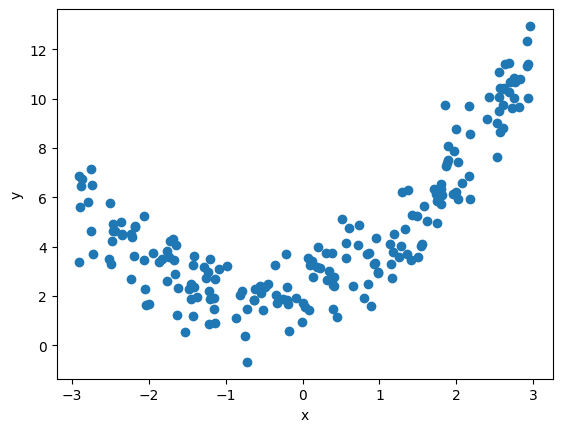

In [10]:
plt.scatter(X,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [12]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3)

In [14]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
r2_score_lr = r2_score(y_test, y_pred)
print("R2-score is: ", r2_score_lr)


R2-score is:  0.26811308651992616


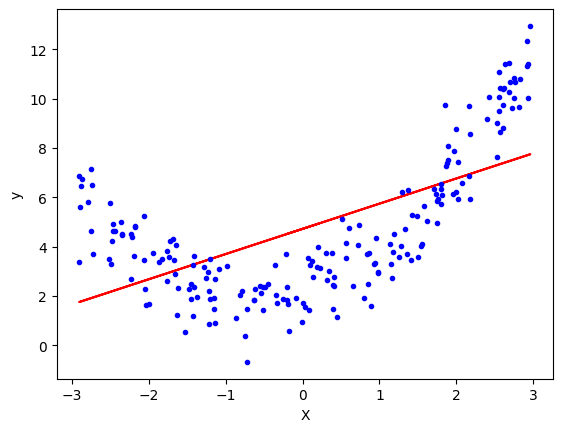

In [18]:
plt.plot(X_train, model.predict(X_train), color='r')
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

#### **Applying Polynomial Linear Regression**

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [21]:
print(X_train[0])

[-0.20563898]


In [22]:
print(X_train_trans[0])

[ 1.         -0.20563898  0.04228739]


In [23]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

LinearRegression()

In [24]:
y_pred = lr.predict(X_test_trans)

In [25]:
r2_score(y_test,y_pred)

0.8069250442168968

In [26]:
print(lr.coef_)

[[0.         0.90602683 0.76764005]]


In [27]:
print(lr.intercept_)

[2.17796862]


In [28]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

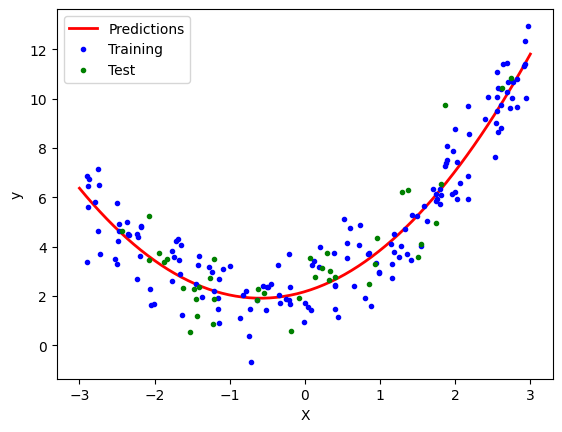

In [29]:
plt.plot(X_new,y_new, "r-", linewidth=2,label='Predictions')
plt.plot(X_train,y_train, "b.",label='Training')
plt.plot(X_test,y_test, "g.",label='Test')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [30]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

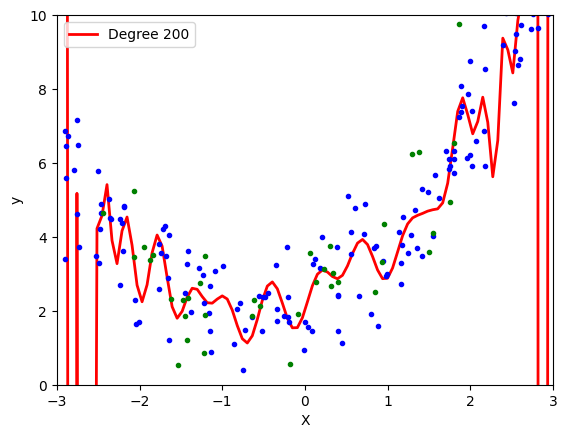

In [31]:
polynomial_regression(200)

In [32]:
poly.powers_

array([[0],
       [1],
       [2]])

In [33]:
# 3D polynomial regression

x = 7*np.random.rand(100,1)-2.8
y = 7*np.random.rand(100,1)-2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.rand(100,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [34]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(), y=y.ravel(), z = z.ravel())
fig.show()